In [4]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1A. Define transforms for TRAINING (Enhanced Augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.RandomRotation(degrees=15),  
    
    # --- NEW AUGMENTATIONS ---
    # Shift the image by up to 10% horizontally or vertically
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), 
    # Randomly change brightness and contrast by up to 20%
    transforms.ColorJitter(brightness=0.2, contrast=0.2),     
    # -------------------------
    
    transforms.ToTensor(),         
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

# 1B. Define transforms for TESTING (NO Augmentation)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),         
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

# 2. Define the paths to your folders
train_dir = '../dataset/training'
test_dir = '../dataset/testing'

# 3. Load the datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

# 4. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 5. Verify the data is loaded correctly
print(f"Training images: {len(train_dataset)} ({len(train_loader)} batches)")
print(f"Testing images: {len(test_dataset)} ({len(test_loader)} batches)")
print(f"Detected classes: {train_dataset.classes}")

Training images: 5600 (175 batches)
Testing images: 1600 (50 batches)
Detected classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [5]:
import torch
import torch.nn as nn
from torchvision import models

# 1. Load the pre-trained ResNet50 model
resnet_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# 2. Inspect and replace the final classification layer
num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, 4)
)

# 3. Move the massive new model to your RTX 3050 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = resnet_model.to(device)

print(f"ResNet50 successfully built and moved to: {device}")

ResNet50 successfully built and moved to: cuda


In [6]:
import torch.optim as nn_optim

criterion = nn.CrossEntropyLoss()
# Lowering learning rate to 0.0001 so we don't break the pre-trained weights
optimizer = nn_optim.Adam(model.parameters(), lr=0.0001)

print("Optimizer configured for ResNet50.")

Optimizer configured for ResNet50.


In [8]:
import time
from tqdm import tqdm

epochs = 10
train_losses = []
val_losses = []
val_accuracies = []
train_accuracies = [] # <--- NEW: List to store training accuracy

print("Starting Training...")

for epoch in range(epochs):
    # =========================
    # 1. TRAINING PHASE
    # =========================
    model.train() 
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    train_loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]', leave=False)
    
    for images, labels in train_loop:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()               
        outputs = model(images)             
        loss = criterion(outputs, labels)   
        loss.backward()                     
        optimizer.step()                    
        
        running_train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
        current_loss = running_train_loss / total_train
        current_acc = 100 * correct_train / total_train
        train_loop.set_postfix(loss=f'{current_loss:.4f}', acc=f'{current_acc:.2f}%')
        
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = 100 * correct_train / total_train
    
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc) # <--- NEW: Save it!
    
    # =========================
    # 2. VALIDATION PHASE
    # =========================
    model.eval() 
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    val_loop = tqdm(test_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]  ', leave=False)
    
    with torch.no_grad(): 
        for images, labels in val_loop:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
            current_vloss = running_val_loss / total_val
            current_vacc = 100 * correct_val / total_val
            val_loop.set_postfix(loss=f'{current_vloss:.4f}', acc=f'{current_vacc:.2f}%')
            
    epoch_val_loss = running_val_loss / len(test_loader.dataset)
    epoch_val_acc = 100 * correct_val / total_val
    
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")

print("Training Complete!")

Starting Training...


Epoch 1/10 | Train Loss: 0.2685, Train Acc: 91.43% | Val Loss: 0.4627, Val Acc: 88.75%


Epoch 2/10 | Train Loss: 0.1272, Train Acc: 95.75% | Val Loss: 0.2494, Val Acc: 94.50%


Epoch 3/10 | Train Loss: 0.0793, Train Acc: 97.43% | Val Loss: 0.3116, Val Acc: 94.44%


Epoch 4/10 | Train Loss: 0.0561, Train Acc: 98.34% | Val Loss: 0.2652, Val Acc: 95.19%


...

Epoch 6/10 | Train Loss: 0.0459, Train Acc: 98.46% | Val Loss: 0.2804, Val Acc: 95.06%


Epoch 7/10 | Train Loss: 0.0223, Train Acc: 99.38% | Val Loss: 0.4415, Val Acc: 93.44%


Epoch 8/10 | Train Loss: 0.0286, Train Acc: 99.02% | Val Loss: 0.2817, Val Acc: 95.56%


Epoch 9/10 | Train Loss: 0.0276, Train Acc: 99.14% | Val Loss: 0.4655, Val Acc: 95.00%


Epoch 10/10 | Train Loss: 0.0265, Train Acc: 99.12% | Val Loss: 0.3427, Val Acc: 94.69%
Training Complete!


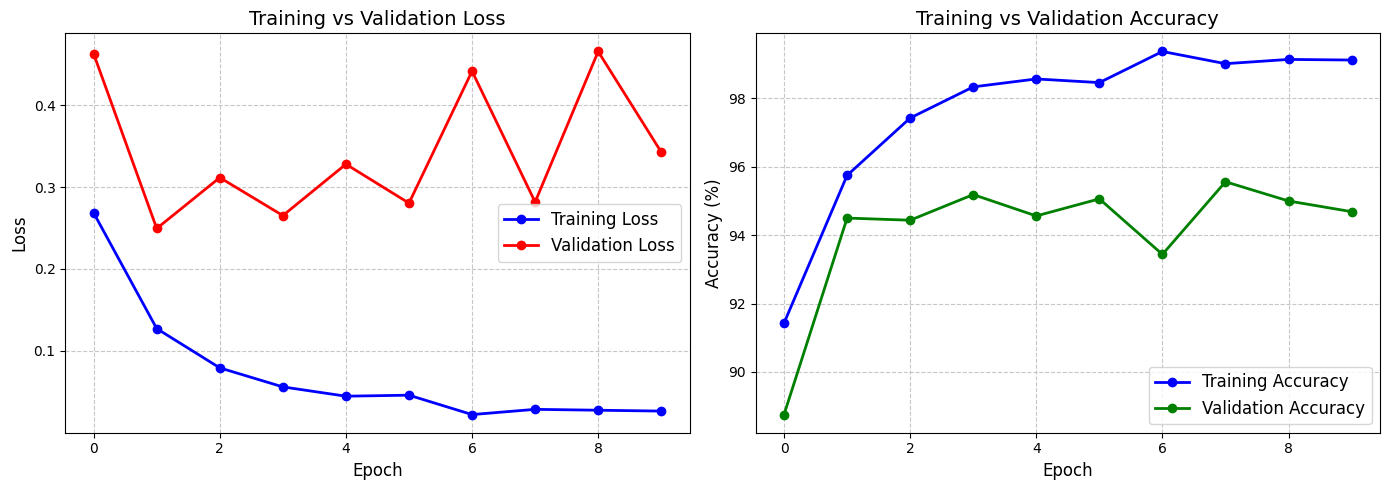

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# =========================
# Graph 1: Loss Comparison
# =========================
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='blue', marker='o', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='red', marker='o', linewidth=2)
plt.title('Training vs Validation Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# =========================
# Graph 2: Accuracy Comparison
# =========================
plt.subplot(1, 2, 2)
# --- NEW: Added Training Accuracy Line ---
plt.plot(train_accuracies, label='Training Accuracy', color='blue', marker='o', linewidth=2) 
plt.plot(val_accuracies, label='Validation Accuracy', color='green', marker='o', linewidth=2)
plt.title('Training vs Validation Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [12]:
import os

# Create the outputs directory if it doesn't exist just to be safe
os.makedirs('../outputs', exist_ok=True)

# Define the path where the model will be saved
model_save_path = '../outputs/tumor_cnn_epoch10.pth'

# Save ONLY the model weights (state_dict), which is the PyTorch best practice
torch.save(model.state_dict(), model_save_path)

print(f"Model successfully saved to: {model_save_path}")

Model successfully saved to: ../outputs/tumor_cnn_epoch10.pth


In [13]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F

# 1. Define the classes exactly as they were loaded earlier
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

# 2. We need the exact same transform used for testing
# (Redefined here so this function can run independently later)
from torchvision import transforms
predict_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def predict_tumor(image_path, trained_model):
    """Takes an image path and a model, and plots the prediction with confidence."""
    # Open the image and force it to RGB (just in case it's grayscale)
    image = Image.open(image_path).convert('RGB')
    
    # Apply the resizing and normalization
    input_tensor = predict_transform(image)
    
    # PyTorch models expect batches (Batch_Size, Channels, Height, Width)
    # We only have 1 image, so we use unsqueeze(0) to fake a batch size of 1
    input_batch = input_tensor.unsqueeze(0).to(device) 
    
    # Put the model in evaluation mode
    trained_model.eval()
    
    with torch.no_grad():
        output = trained_model(input_batch)
        
        # Apply Softmax to convert the raw output numbers into percentages (0 to 1)
        probabilities = F.softmax(output[0], dim=0)
        
        # Get the highest probability and its corresponding class index
        confidence, predicted_idx = torch.max(probabilities, 0)
        
    predicted_class = classes[predicted_idx.item()]
    
    # Display the image alongside the model's guess
    plt.figure(figsize=(6, 6))
    plt.imshow(image) # Show the original, un-normalized image
    plt.title(f"Prediction: {predicted_class.upper()} \nConfidence: {confidence.item()*100:.2f}%", 
              fontsize=14, fontweight='bold', color='darkred')
    plt.axis('off')
    plt.show()

print("Prediction function ready!")

Prediction function ready!


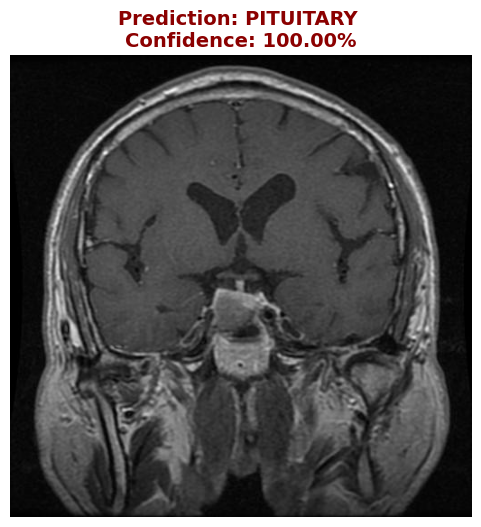

In [14]:
# Replace this string with a real path from your testing folder
sample_path = '../dataset/testing/pituitary/Te-pi_28.jpg' 

predict_tumor(sample_path, model)

In [15]:
import numpy as np
import matplotlib.cm as cm
import torch.nn.functional as F

def generate_gradcam(image_path, model, target_layer):
    """Generates and plots a Grad-CAM heatmap for a given image and model."""
    
    # 1. Prepare the image
    original_img = Image.open(image_path).convert('RGB')
    input_tensor = predict_transform(original_img).unsqueeze(0).to(device)
    
    # Lists to store the data we intercept from the model
    activations = []
    gradients = []
    
    # 2. Define Hooks (Intercepts the data flowing through the layer)
    def forward_hook(module, input, output):
        activations.append(output)
        
    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])
        
    # Attach the hooks to the target layer (e.g., conv4)
    handle_forward = target_layer.register_forward_hook(forward_hook)
    handle_backward = target_layer.register_full_backward_hook(backward_hook)
    
    # 3. Forward Pass
    model.eval() # Ensure dropout is off
    output = model(input_tensor)
    predicted_idx = output.argmax(dim=1).item()
    predicted_class = classes[predicted_idx]
    
    # 4. Backward Pass (Calculate the gradients for the predicted class)
    model.zero_grad()
    output[0, predicted_idx].backward()
    
    # Remove the hooks so they don't interfere with future runs
    handle_forward.remove()
    handle_backward.remove()
    
    # 5. Process the Intercepted Data
    act = activations[0].squeeze() # The feature maps
    grad = gradients[0].squeeze()  # The importance of each map
    
    # Calculate the average importance (weight) of each feature map
    weights = torch.mean(grad, dim=(1, 2))
    
    # Multiply the feature maps by their importance weight
    cam = torch.zeros(act.shape[1:], dtype=torch.float32, device=device)
    for i, w in enumerate(weights):
        cam += w * act[i]
        
    # 6. Formatting the Heatmap
    cam = F.relu(cam) 
    cam = cam - cam.min()
    cam = cam / cam.max() 
    
    # ---> THE FIX IS ON THIS LINE <---
    cam = cam.detach().cpu().numpy() 
    
    # Resize the tiny heatmap back up to the original image size using PIL
    cam_resized = Image.fromarray(cam).resize(original_img.size, resample=Image.BILINEAR)
    cam_resized = np.array(cam_resized)
    
    # 7. Apply Colors and Overlay
    heatmap = cm.jet(cam_resized)[:, :, :3] # Apply the 'jet' color scheme (Red=High, Blue=Low)
    img_array = np.array(original_img) / 255.0
    overlay = 0.5 * heatmap + 0.5 * img_array # Blend image and heatmap
    overlay = np.clip(overlay, 0, 1)
    
    # 8. Plot the Results
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title(f"Original Scan", fontsize=14)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title(f"Grad-CAM (Focus Area)\nPrediction: {predicted_class.upper()}", fontsize=14, fontweight='bold', color='darkred')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

print("Grad-CAM function ready!")

Grad-CAM function ready!


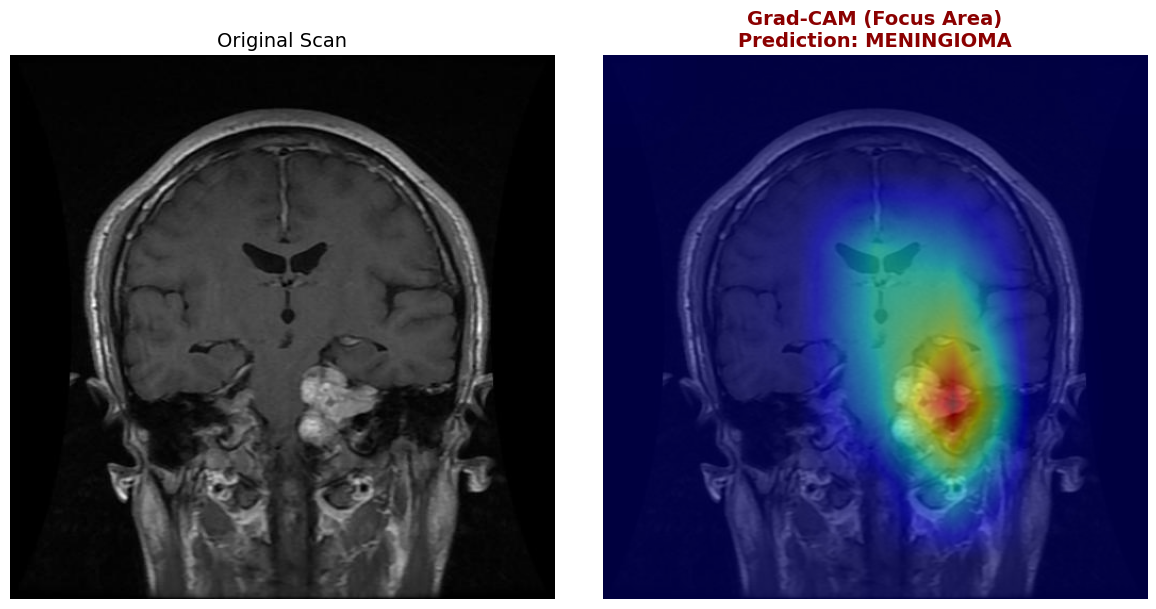

In [21]:
# Use the same sample path you used for the basic prediction test!
sample_path = '../dataset/Testing/meningioma/Te-me_291.jpg' 

# Run Grad-CAM
generate_gradcam(sample_path, model, model.layer4[-1])